# Customer Churn Prediction
An end-to-end Machine Learning project to analyze customer demographic, account, and service usage data to predict customer churn using **Logistic Regression** and **Random Forest Classifiers**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load Telco Customer Churn Dataset
df = pd.read_excel("data/Telco_customer_churn.xlsx")
print("Dataset Shape:", df.shape)
print("
First 5 Rows:")
df.head()


Error: unterminated string literal (detected at line 4) (<string>, line 4)

In [3]:
print("Dataset Info:")
df.info()
print("
Summary Statistics:")
df.describe()


Error: unterminated string literal (detected at line 3) (<string>, line 3)

In [4]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")


Error: name 'df' is not defined


Error: name 'df' is not defined

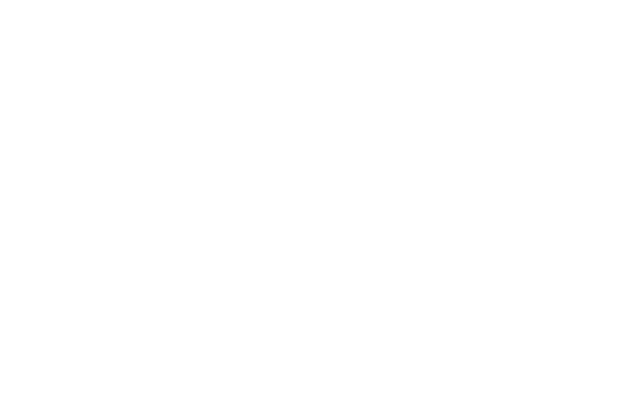

In [5]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn Label', data=df, palette='Set2')
plt.title("Customer Churn Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Churn Label", fontsize=12)
plt.ylabel("Count", fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()


Error: name 'df' is not defined

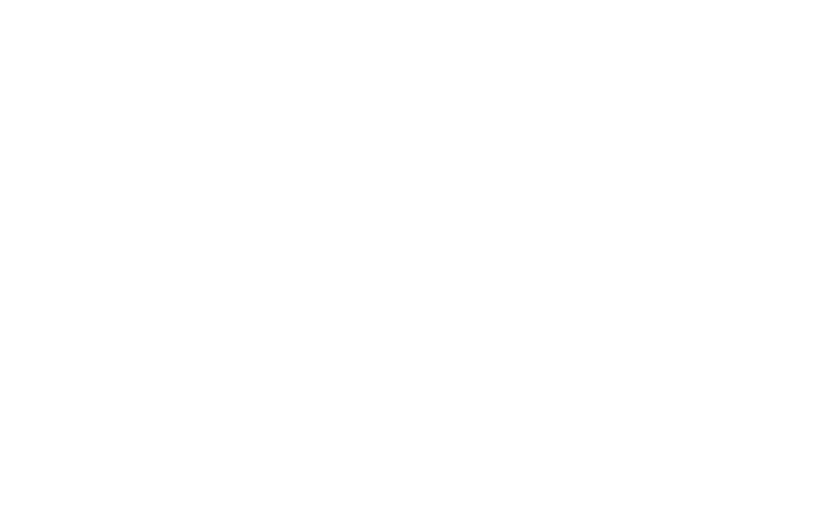

In [6]:
plt.figure(figsize=(8, 5))
df['CLTV'].hist(bins=30, color='teal', edgecolor='black', alpha=0.7)
plt.title('Customer Lifetime Value (CLTV) Distribution', fontsize=14, fontweight='bold')
plt.xlabel('CLTV', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()


Error: name 'df' is not defined

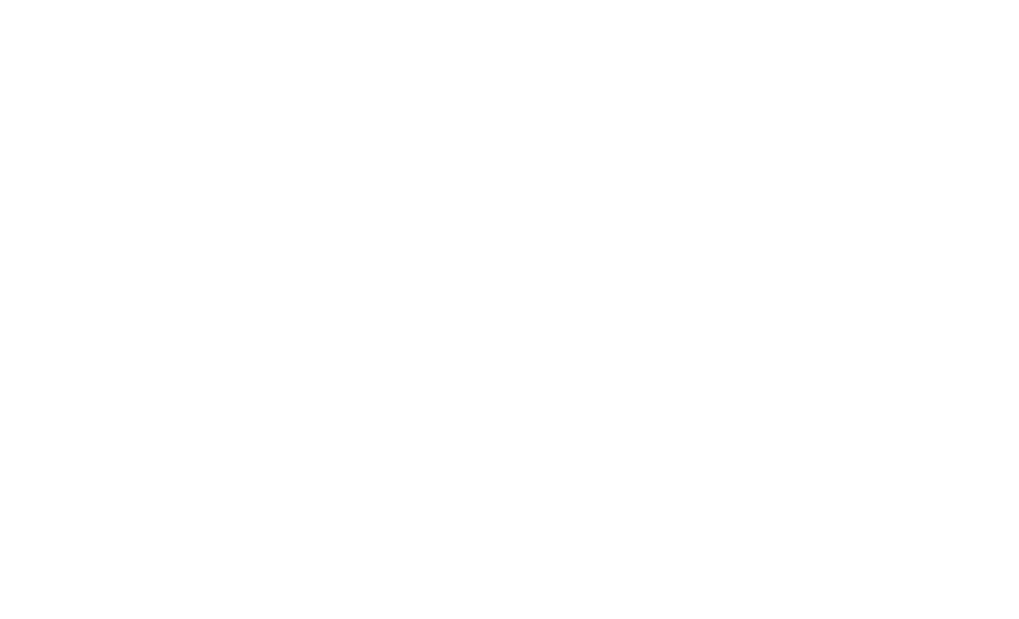

In [7]:
plt.figure(figsize=(10, 6))
numerical_cols = df.select_dtypes(include=['number'])
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Error: name 'df' is not defined

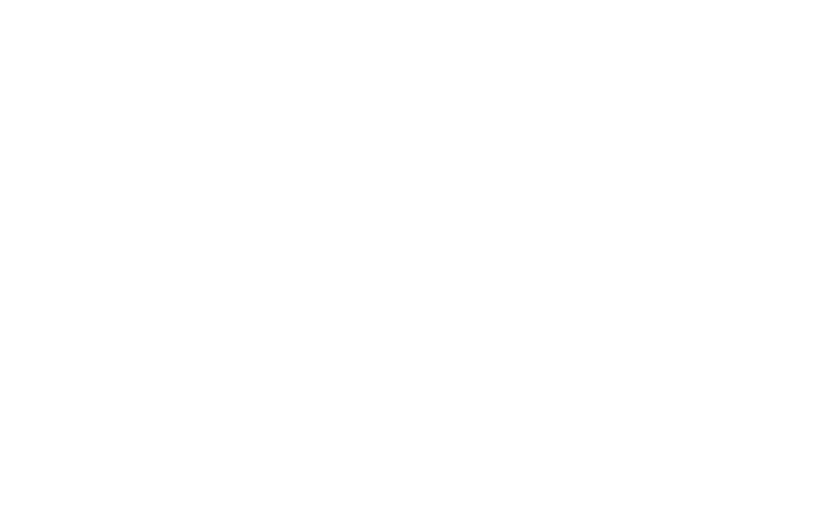

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn Label', data=df, palette='Set1')
plt.title('Churn by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
# Prepare dataset for training
df_model = df.copy()

# Drop non-informative / unique columns
cols_to_drop = ['CustomerID', 'Lat Long', 'Churn Reason', 'Count', 'State', 'Country', 'Zip Code', 'City']
existing_drops = [c for c in cols_to_drop if c in df_model.columns]
df_model.drop(columns=existing_drops, inplace=True)

# Clean Total Charges if necessary
if 'Total Charges' in df_model.columns:
    df_model['Total Charges'] = pd.to_numeric(df_model['Total Charges'], errors='coerce')

# Drop NA rows
df_model.dropna(inplace=True)

# Encode categorical columns
label_encoders = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != 'Churn Label':
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        label_encoders[col] = le

# Separate features (X) and target (y)
X = df_model.drop(columns=['Churn Value', 'Churn Label'], errors='ignore')
y = df_model['Churn Value']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")


Error: name 'df' is not defined

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Samples: {X_train.shape[0]}")
print(f"Testing Samples: {X_test.shape[0]}")


Error: name 'X' is not defined

In [11]:
# Logistic Regression Model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)

print(f"Logistic Regression Accuracy: {lr_acc * 100:.2f}%
")
print("Classification Report:
", classification_report(y_test, lr_pred))


Error: unterminated string literal (detected at line 8) (<string>, line 8)

In [12]:
# Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_acc * 100:.2f}%
")
print("Classification Report:
", classification_report(y_test, rf_pred))


Error: unterminated string literal (detected at line 8) (<string>, line 8)


Error: name 'y_test' is not defined

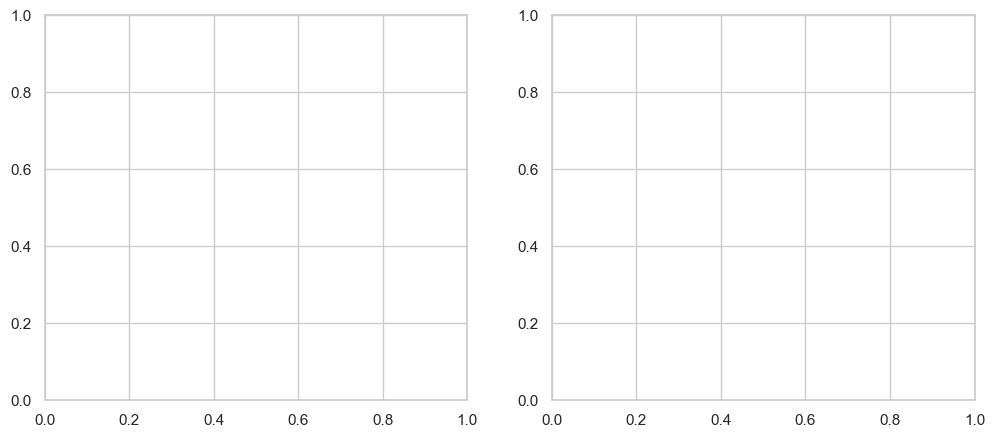

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()